In [10]:
import pandas as pd

df = pd.read_csv("C:\\Users\\lisaj\\OneDrive\\바탕 화면\\프로젝트\\Total_Data_v2.csv", encoding='utf-8')

# print(df.info())


print(df.head())


   Unnamed: 0     가맹점구분번호        기준년월 가맹점 운영개월수 구간   매출금액 구간   매출건수 구간  \
0        8768  13D9737A1D  2023-01-01     3_25-50%  2_10-25%   1_10%이하   
1       72685  D89DEC9B29  2023-01-01     4_50-75%   1_10%이하   1_10%이하   
2       39069  E6BF54CE96  2023-01-01     5_75-90%  4_50-75%   1_10%이하   
3       39065  E6738F086C  2023-01-01     5_75-90%  5_75-90%  4_50-75%   
4       39063  E629D92144  2023-01-01     3_25-50%  2_10-25%  3_25-50%   

  유니크 고객 수 구간    객단가 구간   취소율 구간  배달매출금액 비율  ...  매출금액 구간_회복지수_6개월  \
0     1_10%이하  5_75-90%  5_상위5구간       15.4  ...               NaN   
1     1_10%이하  4_50-75%  3_상위3구간       22.7  ...               NaN   
2    2_10-25%  5_75-90%  5_상위5구간        9.6  ...               0.0   
3    4_50-75%  5_75-90%  1_상위1구간  -999999.9  ...               NaN   
4    3_25-50%  2_10-25%  1_상위1구간  -999999.9  ...               NaN   

   급감여부(-20% YoY)  매출 안정성(변동성) CV(3개월)  매출탄력도(6개월)  매출 안정성(변동성) 여부  \
0             0.0         0.000000e+00     0.00000             0

In [11]:
print(df.columns)

Index(['Unnamed: 0', '가맹점구분번호', '기준년월', '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간',
       '유니크 고객 수 구간', '객단가 구간', '취소율 구간', '배달매출금액 비율', '동일 업종 매출금액 비율_x',
       '동일 업종 매출건수 비율', '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율_x',
       '동일 업종 내 해지 가맹점 비중_x', '동일 상권 내 해지 가맹점 비중', '남성 20대이하 고객 비중',
       '남성 30대 고객 비중', '남성 40대 고객 비중', '남성 50대 고객 비중', '남성 60대이상 고객 비중',
       '여성 20대이하 고객 비중', '여성 30대 고객 비중', '여성 40대 고객 비중', '여성 50대 고객 비중',
       '여성 60대이상 고객 비중', '재방문 고객 비중_x', '신규 고객 비중', '거주 이용 고객 비율',
       '직장 이용 고객 비율', '유동인구 이용 고객 비율', '가맹점주소', '가맹점명', '브랜드구분코드', '가맹점지역',
       '업종', '상권', '개설일', '폐업일', '기준년월_최신', '전월대비 매출금액 감소율(%)', '3개월 연속 감소 여부',
       '6개월 하락추세 여부', '매출금액 구간_회복지수_6개월', '급감여부(-20% YoY)',
       '매출 안정성(변동성) CV(3개월)', '매출탄력도(6개월)', '매출 안정성(변동성) 여부',
       '동일 상권 내 매출 순위 비율_y', '동일 업종 내 해지 가맹점 비중_y', '고객분포_다양성지수',
       '동일 업종 매출금액 비율_y', '재방문 고객 비중_y'],
      dtype='object')


In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 53 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           86590 non-null  int64  
 1   가맹점구분번호              86590 non-null  object 
 2   기준년월                 86590 non-null  object 
 3   가맹점 운영개월수 구간         86590 non-null  object 
 4   매출금액 구간              86590 non-null  object 
 5   매출건수 구간              86590 non-null  object 
 6   유니크 고객 수 구간          86590 non-null  object 
 7   객단가 구간               86590 non-null  object 
 8   취소율 구간               79958 non-null  object 
 9   배달매출금액 비율            86590 non-null  float64
 10  동일 업종 매출금액 비율_x      86590 non-null  float64
 11  동일 업종 매출건수 비율        86590 non-null  float64
 12  동일 업종 내 매출 순위 비율     86590 non-null  float64
 13  동일 상권 내 매출 순위 비율_x   86590 non-null  float64
 14  동일 업종 내 해지 가맹점 비중_x  86590 non-null  float64
 15  동일 상권 내 해지 가맹점 비중    86590 non-null 

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from collections import defaultdict 

# 데이터프레임 df가 이미 로드되었다고 가정합니다.

# 1. 목표 변수(Y) 정의 (폐업 여부)
# '급감여부(-20% YoY)'를 폐업 프록시로 사용합니다. NaN은 급감하지 않은(0)으로 처리합니다.
df['폐업_FLAG'] = df['급감여부(-20% YoY)'].fillna(0).astype(int) 

# 2. 이상치 및 결측치 처리
# '-999999.9'를 NaN으로 변환
df = df.replace(-999999.9, np.nan)

# 수치형 변수 목록 (NaN 처리가 필요한 연속형 변수)
numerical_cols = [
    '배달매출금액 비율', '매출 안정성(변동성) CV(3개월)', '매출탄력도(6개월)',
    '동일 상권 내 매출 순위 비율_y', '동일 업종 내 해지 가맹점 비중_y', 
    '고객분포_다양성지수', '재방문 고객 비중_y'
]

# 수치형 변수 결측치 중앙값 대체
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col].median())

# 3. 구간 변수 (Ordinal) 인코딩 및 점수화 준비
segment_cols = [
    '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', 
    '유니크 고객 수 구간', '객단가 구간', '취소율 구간'
]

for col in segment_cols:
    # 1. 문자열 '5_75-90%' 등에서 '5'와 같은 숫자 부분만 추출
    score_col_name = col + '_SCORE'
    
    # astype(str)을 먼저 적용하여 문자열 처리가 가능하게 함
    extracted_score = df[col].astype(str).str.split('_').str[0]

    # 2. 추출된 문자열을 숫자로 변환 (변환 불가 시 errors='coerce'로 NaN 처리)
    numeric_score = pd.to_numeric(extracted_score, errors='coerce')
    
    # 3. NaN 값(변환 실패 값)을 0으로 대체 후, 안전하게 정수(int)로 변환
    df[score_col_name] = numeric_score.fillna(0).astype(int)

# 4. '취소율 구간' 역순 점수 변환
df['취소율_역순_SCORE'] = 6 - df['취소율 구간_SCORE']

In [14]:
# Min-Max Scaler 초기화
scaler = MinMaxScaler()

# 5. 각 영역별 변수 정의 및 점수화 (0~1)

### 5-1. 영역 1: 거래 안정성 (Stability) ###
stability_cols = ['매출 안정성(변동성) CV(3개월)', '취소율_역순_SCORE'] 
stability_df = df[stability_cols].copy()

# CV는 낮을수록 좋으니 (1 - 값)
stability_df['매출CV_정규화'] = 1 - scaler.fit_transform(stability_df[['매출 안정성(변동성) CV(3개월)']]) 
# 취소율 역순점수는 높을수록 좋으니 그대로 정규화
stability_df['취소율_정규화'] = scaler.fit_transform(stability_df[['취소율_역순_SCORE']]) 

### 5-2. 영역 2: 매출 (Sales) ###
sales_cols = ['매출금액 구간_SCORE', '매출건수 구간_SCORE', '배달매출금액 비율'] 
sales_df = df[sales_cols].copy()
sales_df = pd.DataFrame(scaler.fit_transform(sales_df), columns=[f'{c}_정규화' for c in sales_cols], index=sales_df.index)

### 5-3. 영역 3: 상대적 평가 (Relative) ###
relative_cols = ['동일 상권 내 매출 순위 비율_y', '동일 업종 내 해지 가맹점 비중_y'] 
relative_df = df[relative_cols].copy()

# 순위 비율과 해지 비중은 낮을수록 좋으니 (1 - 값)
relative_df['순위_정규화'] = 1 - scaler.fit_transform(relative_df[['동일 상권 내 매출 순위 비율_y']])
relative_df['해지비중_정규화'] = 1 - scaler.fit_transform(relative_df[['동일 업종 내 해지 가맹점 비중_y']])

### 5-4. 영역 4: 고객 특성 (Customer) ###
customer_cols = ['유니크 고객 수 구간_SCORE', '객단가 구간_SCORE', '고객분포_다양성지수', '재방문 고객 비중_y'] 
customer_df = df[customer_cols].copy()
customer_df = pd.DataFrame(scaler.fit_transform(customer_df), columns=[f'{c}_정규화' for c in customer_cols], index=customer_df.index)

# 6. 종합 점수 생성 (가중치 없는 평균 사용)
df['score_거래 안정성'] = stability_df[['매출CV_정규화', '취소율_정규화']].mean(axis=1)
df['score_매출'] = 1 - sales_df.mean(axis=1)
df['score_상대적 평가'] = relative_df[['순위_정규화', '해지비중_정규화']].mean(axis=1)
df['score_고객 특성'] = customer_df.mean(axis=1)

# X 변수 준비
X = df[['score_거래 안정성', 'score_매출', 'score_상대적 평가', 'score_고객 특성']]
y = df['폐업_FLAG']

# 최종 X 변수 스케일링 (로지스틱 회귀에 사용될 최종 피처)
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 학습/테스트 분리 (클래스 불균형을 고려하여 stratify=y 적용)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
# Grid Search를 통한 최적 파라미터 탐색
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear'] 
}

# 개선 전략 적용: class_weight='balanced' 추가 (Recall 개선 목적)
logreg_base = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# 최적 모델 탐색 (ROC AUC 기준)
grid_search = GridSearchCV(
    logreg_base,
    param_grid, cv=5, scoring='roc_auc', verbose=1, n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("\n### 3. Grid Search 최적 파라미터 탐색 결과 (불균형 처리) ###")
print("최적 하이퍼파라미터:", grid_search.best_params_)
print(f"최적 ROC AUC Score (교차 검증): {grid_search.best_score_:.4f}")

# 최적 모델 성능 평가
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\n### 최적화된 로지스틱 회귀 모델 (Test Set) 성능 ###")
print(classification_report(y_test, y_pred_best, target_names=['운영 중 (0)', '폐업 시그널 (1)']))
print(f"Test Set ROC AUC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")

# 변수 해석 (회귀 계수)
coef_df = pd.DataFrame({'점수 영역': X.columns, '회귀 계수': best_model.coef_[0]})
print("\n### 최적 모델의 회귀 계수 (점수 영역별 영향력) ###")
print(coef_df.sort_values(by='회귀 계수', ascending=True))

Fitting 5 folds for each of 10 candidates, totalling 50 fits

### 3. Grid Search 최적 파라미터 탐색 결과 (불균형 처리) ###
최적 하이퍼파라미터: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
최적 ROC AUC Score (교차 검증): 0.6321

### 최적화된 로지스틱 회귀 모델 (Test Set) 성능 ###
              precision    recall  f1-score   support

    운영 중 (0)       0.87      0.61      0.72     14449
  폐업 시그널 (1)       0.22      0.56      0.32      2869

    accuracy                           0.60     17318
   macro avg       0.55      0.59      0.52     17318
weighted avg       0.77      0.60      0.65     17318

Test Set ROC AUC: 0.6222

### 최적 모델의 회귀 계수 (점수 영역별 영향력) ###
          점수 영역     회귀 계수
1      score_매출 -2.263235
0  score_거래 안정성 -1.280968
2  score_상대적 평가 -0.826396
3   score_고객 특성 -0.180917


In [16]:
print("\n" + "=" * 50)
print("4. 업종별 로지스틱 회귀 모델 분석")
print("=" * 50)

industry_results = defaultdict(dict)
unique_industries = df['업종'].dropna().unique()
best_params = grid_search.best_params_

for biz in unique_industries:
    sub_df = df[df['업종'] == biz].copy()

    # 데이터 부족 및 폐업 시그널 부족 시 건너뛰기 (폐업 시그널이 10개 미만이면 학습 어려움)
    if len(sub_df) < 100 or sub_df['폐업_FLAG'].sum() < 10:
        continue

    X_biz = sub_df[['score_거래 안정성', 'score_매출', 'score_상대적 평가', 'score_고객 특성']]
    y_biz = sub_df['폐업_FLAG']

    # 업종 내 분포 기준으로 다시 스케일링 적용 (매우 중요)
    X_biz_scaled = scaler.fit_transform(X_biz)
    X_biz_scaled = pd.DataFrame(X_biz_scaled, columns=X_biz.columns)

    # 학습/테스트 분리
    X_train_biz, X_test_biz, y_train_biz, y_test_biz = train_test_split(
        X_biz_scaled, y_biz, test_size=0.3, random_state=42, stratify=y_biz
    )
    
    try:

        biz_model = LogisticRegression(
            penalty=best_params['penalty'], 
            C=best_params['C'], 
            solver=best_params['solver'],
            max_iter=1000, 
            random_state=42,
            class_weight='balanced'
        )
        biz_model.fit(X_train_biz, y_train_biz)
        
        y_pred_proba_biz = biz_model.predict_proba(X_test_biz)[:, 1]
        roc_auc_biz = roc_auc_score(y_test_biz, y_pred_proba_biz)
        
        # 결과 저장
        industry_results[biz]['ROC_AUC'] = roc_auc_biz
        industry_results[biz]['계수'] = dict(zip(X_biz.columns, biz_model.coef_[0]))

        print(f"[{biz}] ROC AUC: {roc_auc_biz:.4f}")

    except Exception as e:
        print(f"[{biz}] 모델 학습 오류: {e}")

# 최종 업종별 결과 요약
print("\n최종 업종별 모델 ROC AUC 및 계수 요약:")
summary_df = pd.DataFrame.from_dict(industry_results, orient='index')
# print(summary_df.sort_values(by='ROC_AUC', ascending=False))


4. 업종별 로지스틱 회귀 모델 분석
[햄버거] ROC AUC: 0.9235
[커피전문점] ROC AUC: 0.6359
[베이커리] ROC AUC: 0.8281
[한식-육류/고기] ROC AUC: 0.6798
[일반 유흥주점] ROC AUC: 0.6739
[양식] ROC AUC: 0.7150
[한식-단품요리일반] ROC AUC: 0.6396
[한식-국밥/설렁탕] ROC AUC: 0.7358
[치킨] ROC AUC: 0.7135
[분식] ROC AUC: 0.6769
[카페] ROC AUC: 0.5916
[일식당] ROC AUC: 0.5828
[백반/가정식] ROC AUC: 0.6109
[한식-국수/만두] ROC AUC: 0.5977
[동남아/인도음식] ROC AUC: 0.8927
[농산물] ROC AUC: 0.6937
[떡/한과 제조] ROC AUC: 0.5630
[중식당] ROC AUC: 0.8033
[요리주점] ROC AUC: 0.5589
[와인바] ROC AUC: 0.5745
[한식뷔페] ROC AUC: 0.7430
[한식-해물/생선] ROC AUC: 0.6859
[호프/맥주] ROC AUC: 0.7176
[피자] ROC AUC: 0.7654
[한식-감자탕] ROC AUC: 0.8850
[샌드위치/토스트] ROC AUC: 0.8587
[반찬] ROC AUC: 0.7101
[미곡상] ROC AUC: 0.9341
[식료품] ROC AUC: 0.6638
[청과물] ROC AUC: 0.5712
[일식-우동/소바/라면] ROC AUC: 0.9314
[축산물] ROC AUC: 0.5299
[주류] ROC AUC: 0.8040
[꼬치구이] ROC AUC: 1.0000
[아이스크림/빙수] ROC AUC: 0.6876
[포장마차] ROC AUC: 0.7338
[한식-죽] ROC AUC: 1.0000
[일식-초밥/롤] ROC AUC: 1.0000
[이자카야] ROC AUC: 0.8344
[룸살롱/단란주점] ROC AUC: 0.9718
[한식-찌개/전골] ROC AUC: 0

In [17]:
import pandas as pd

# 업종별 ROC AUC 값 딕셔너리 생성
roc_auc_dict = {
    "햄버거": 0.9235,
    "커피전문점": 0.6359,
    "베이커리": 0.8281,
    "한식-육류/고기": 0.6798,
    "일반 유흥주점": 0.6739,
    "양식": 0.7150,
    "한식-단품요리일반": 0.6396,
    "한식-국밥/설렁탕": 0.7358,
    "치킨": 0.7135,
    "분식": 0.6769,
    "카페": 0.5916,
    "일식당": 0.5828,
    "백반/가정식": 0.6109,
    "한식-국수/만두": 0.5977,
    "동남아/인도음식": 0.8927,
    "농산물": 0.6937,
    "떡/한과 제조": 0.5630,
    "중식당": 0.8033,
    "요리주점": 0.5589,
    "와인바": 0.5745,
    "한식뷔페": 0.7430,
    "한식-해물/생선": 0.6859,
    "호프/맥주": 0.7176,
    "피자": 0.7654,
    "한식-감자탕": 0.8850,
    "샌드위치/토스트": 0.8587,
    "반찬": 0.7101,
    "미곡상": 0.9341,
    "식료품": 0.6638,
    "청과물": 0.5712,
    "일식-우동/소바/라면": 0.9314,
    "축산물": 0.5299,
    "주류": 0.8040,
    "꼬치구이": 1.0000,
    "아이스크림/빙수": 0.6876,
    "포장마차": 0.7338,
    "한식-죽": 1.0000,
    "일식-초밥/롤": 1.0000,
    "이자카야": 0.8344,
    "룸살롱/단란주점": 0.9718,
    "한식-찌개/전골": 0.7810,
    "인삼제품": 0.9353,
    "한식-냉면": 0.7790,
    "일식-덮밥/돈가스": 0.7305,
    "식품 제조": 0.7510,
    "떡/한과": 0.9600,
    "기타세계요리": 0.6636,
    "도시락": 1.0000,
    "건강식품": 0.9100,
    "담배": 1.0000
}

# 데이터프레임으로 변환
summary_df = pd.DataFrame(list(roc_auc_dict.items()), columns=['업종', 'ROC_AUC'])

# ROC_AUC 기준 내림차순 정렬
summary_df = summary_df.sort_values(by='ROC_AUC', ascending=False).reset_index(drop=True)

print(summary_df)


             업종  ROC_AUC
0           도시락   1.0000
1          꼬치구이   1.0000
2       일식-초밥/롤   1.0000
3          한식-죽   1.0000
4            담배   1.0000
5      룸살롱/단란주점   0.9718
6          떡/한과   0.9600
7          인삼제품   0.9353
8           미곡상   0.9341
9   일식-우동/소바/라면   0.9314
10          햄버거   0.9235
11         건강식품   0.9100
12     동남아/인도음식   0.8927
13       한식-감자탕   0.8850
14     샌드위치/토스트   0.8587
15         이자카야   0.8344
16         베이커리   0.8281
17           주류   0.8040
18          중식당   0.8033
19     한식-찌개/전골   0.7810
20        한식-냉면   0.7790
21           피자   0.7654
22        식품 제조   0.7510
23         한식뷔페   0.7430
24    한식-국밥/설렁탕   0.7358
25         포장마차   0.7338
26    일식-덮밥/돈가스   0.7305
27        호프/맥주   0.7176
28           양식   0.7150
29           치킨   0.7135
30           반찬   0.7101
31          농산물   0.6937
32     아이스크림/빙수   0.6876
33     한식-해물/생선   0.6859
34     한식-육류/고기   0.6798
35           분식   0.6769
36      일반 유흥주점   0.6739
37          식료품   0.6638
38       기타세계요리   0.6636


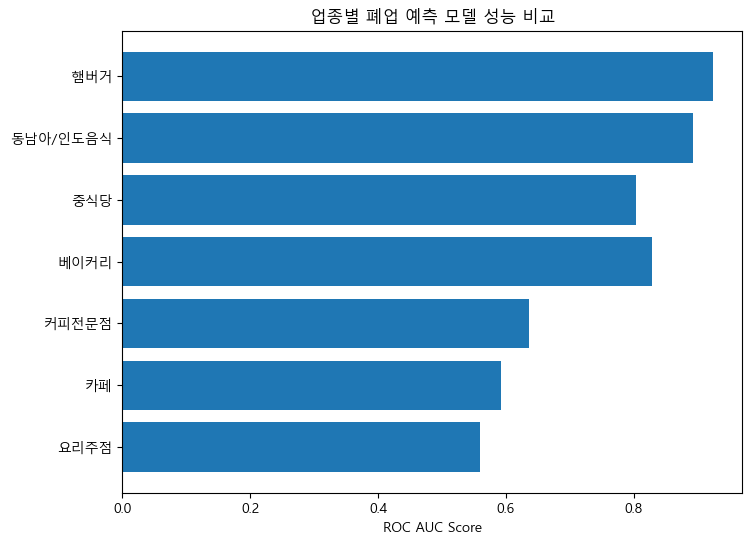

In [18]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우: 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지


# 예시 데이터
roc_by_category = {
    '햄버거': 0.9235, '동남아/인도음식': 0.8927, '중식당': 0.8033, '베이커리': 0.8281,
    '커피전문점': 0.6359, '카페': 0.5916, '요리주점': 0.5589
}

plt.figure(figsize=(8,6))
plt.barh(list(roc_by_category.keys()), list(roc_by_category.values()))
plt.xlabel('ROC AUC Score')
plt.title('업종별 폐업 예측 모델 성능 비교')
plt.gca().invert_yaxis()
plt.show()


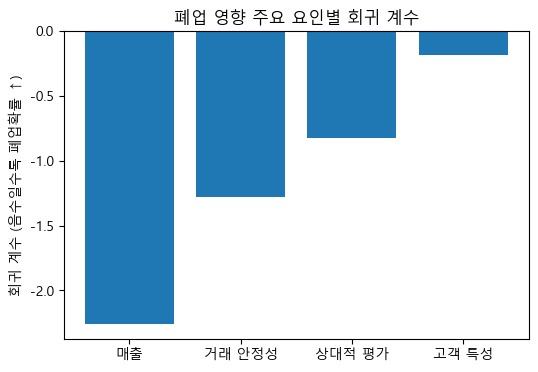

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    '점수영역': ['매출', '거래 안정성', '상대적 평가', '고객 특성'],
    '회귀계수': [-2.263, -1.281, -0.826, -0.181]
})

plt.figure(figsize=(6,4))
plt.bar(coef_df['점수영역'], coef_df['회귀계수'])
plt.title('폐업 영향 주요 요인별 회귀 계수')
plt.ylabel('회귀 계수 (음수일수록 폐업확률 ↑)')
plt.show()


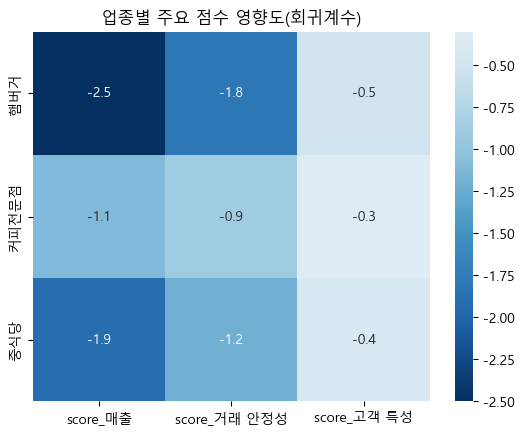

In [20]:
import seaborn as sns

# 예시: 업종별 주요 score 영향
data = {
    '햄버거': {'score_매출': -2.5, 'score_거래 안정성': -1.8, 'score_고객 특성': -0.5},
    '커피전문점': {'score_매출': -1.1, 'score_거래 안정성': -0.9, 'score_고객 특성': -0.3},
    '중식당': {'score_매출': -1.9, 'score_거래 안정성': -1.2, 'score_고객 특성': -0.4}
}

df_heat = pd.DataFrame(data).T  # 전치
sns.heatmap(df_heat, annot=True, cmap="RdBu_r", center=0)
plt.title("업종별 주요 점수 영향도(회귀계수)")
plt.show()


In [21]:
roc_df = pd.DataFrame(list(roc_by_category.items()), columns=['업종', 'ROC_AUC'])
roc_df.sort_values('ROC_AUC', ascending=False).head(5)

# roc_df.sort_values('ROC_AUC', ascending=False).tail(5)


,업종,ROC_AUC
0,햄버거,0.9235
1,동남아/인도음식,0.8927
3,베이커리,0.8281
2,중식당,0.8033
4,커피전문점,0.6359


In [22]:
import pandas as pd

perf_df = pd.DataFrame({
    '지표': ['정확도', '폐업 Recall', 'ROC AUC'],
    '값': [0.60, 0.56, 0.622]
})
perf_df



,지표,값
0,정확도,0.600
1,폐업 Recall,0.560
2,ROC AUC,0.622


ROC AUC: 0.8136357222930058

분류 리포트:
               precision    recall  f1-score   support

           0       0.94      0.71      0.81     14449
           1       0.34      0.76      0.47      2869

    accuracy                           0.72     17318
   macro avg       0.64      0.73      0.64     17318
weighted avg       0.84      0.72      0.75     17318



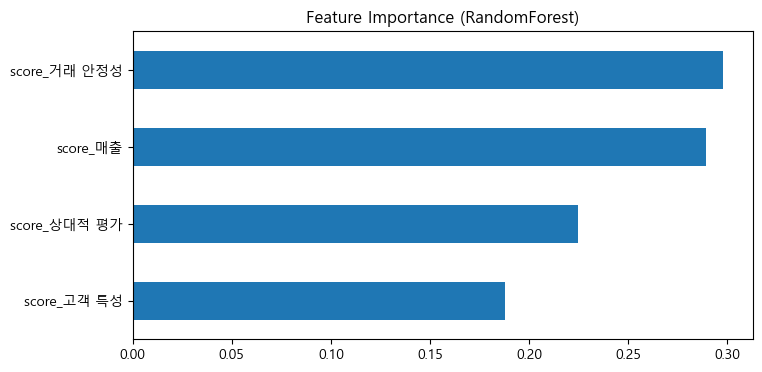

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. 모델 정의
rf_clf = RandomForestClassifier(
    n_estimators=300,      # 트리 개수
    max_depth=8,           # 트리 깊이
    min_samples_split=10,  # 내부 노드 분할 최소 샘플 수
    min_samples_leaf=5,    # 리프 노드 최소 샘플 수
    random_state=42,
    class_weight='balanced'  # 클래스 불균형 자동 보정
)

# 2. 학습
rf_clf.fit(X_train, y_train)

# 3. 예측
y_pred_prob = rf_clf.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob > 0.5).astype(int)

# 4. 평가
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))
print("\n분류 리포트:\n", classification_report(y_test, y_pred))

# 5. (선택) 중요 변수 시각화
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(rf_clf.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(8,4))
plt.title("Feature Importance (RandomForest)")
plt.show()


가맹점 단위 폐업 위험 상위 10개:
      가맹점구분번호   폐업_예측확률
0  6F97F23CDB  0.815970
1  B683D261A6  0.810078
2  014A6A2154  0.809716
3  F701A56FBD  0.806676
4  D749124593  0.806045
5  4F7FF335EF  0.805966
6  377472828B  0.803899
7  C1A729DDD7  0.799205
8  3BCE6D8224  0.799081
9  5FAF6E0F7F  0.795893


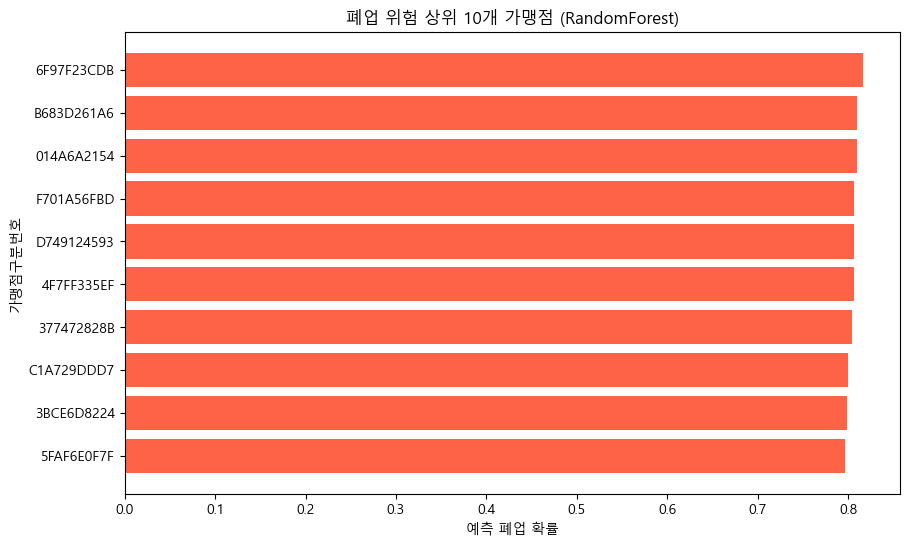

In [32]:
# 1️⃣ 예측 확률 추가
df['폐업_예측확률'] = rf_clf.predict_proba(X_scaled)[:, 1]

# 2️⃣ 가맹점 단위 평균 리스크 계산
risk_by_store = (
    df.groupby('가맹점구분번호')['폐업_예측확률']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# 3️⃣ 폐업 위험 상위 10개 가맹점 출력
print("가맹점 단위 폐업 위험 상위 10개:")
print(risk_by_store.head(10))

# 4️⃣ 시각화 (선택)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(
    risk_by_store['가맹점구분번호'].head(10),
    risk_by_store['폐업_예측확률'].head(10),
    color='tomato'
)
plt.gca().invert_yaxis()
plt.title('폐업 위험 상위 10개 가맹점 (RandomForest)')
plt.xlabel('예측 폐업 확률')
plt.ylabel('가맹점구분번호')
plt.show()


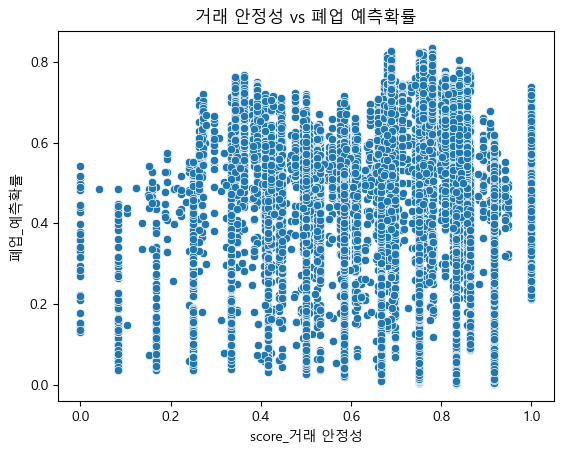

In [30]:
import seaborn as sns
sns.scatterplot(x=df['score_거래 안정성'], y=df['폐업_예측확률'])
plt.title("거래 안정성 vs 폐업 예측확률")
plt.show()


In [31]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df.groupby('Cluster')[['score_거래 안정성', 'score_매출', '폐업_FLAG']].mean()


,score_거래 안정성,score_매출,폐업_FLAG
Cluster,,,
0,0.552809,0.713384,0.149189
1,0.864562,0.721222,0.133939
2,0.862479,0.402692,0.218369
